棋局复杂度与棋手失误类型的关系

# Complexity 高低 → Blunder / Mistake 发生概率

In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

csv_path=r"C:\Users\Administrator\Desktop\Chess\data\input\complex.csv"
df=pd.read_csv(csv_path)

In [2]:
def parse_chess_data(df):
    df['Stage Analysis'] = df['Stage Analysis'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    list_cols = ['Evaluation', 'Judgments', 'Complexity E1', 'Complexity E2', 'Complexity P', 'Complexity S']
    
    for col in list_cols:
        df[col] = df[col].apply(lambda x: [float(i) for i in x.split(',')] if isinstance(x, str) and col != 'Judgments' else x)
        
    df['Judgments'] = df['Judgments'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
    return df
df=parse_chess_data(df)
df.head()

,row_idx,White,Black,White CP Loss,White Accuracy,Black CP Loss,Black Accuracy,Stage Analysis,Evaluation,Judgments,...,Black Blunders,Black Mistakes,Black Inaccuracies,Complexity E1,Complexity E2,Complexity P,Complexity S,White Complexity Sum,Black Complexity Sum,source_file
0,0,Petra Kejzar,Daniel Barria,40.923077,74.704040,4.923077,98.665170,{'beginning': {'white': {'accuracy': 99.041508...,"[0.2, 0.2, 0.2, 0.21, 0.2, 0.33, 0.31, 0.34, 0...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,0,0,0,"[32.0, -20.0, 20.0, -20.0, 21.0, -20.0, 33.0, ...","[23.0, -25.0, 19.0, -32.0, 19.0, -31.0, 23.0, ...","[0.711, 0.622, 0.525, 0.769, 0.55, 0.75, 0.731...","[0.492, 0.684, 0.93, 0.38, 0.863, 0.415, 0.452...",5.710831,5.675668,backup_results_rank_0.csv
1,1,Nataliya Buksa,Jorge Carlos Antonio,17.500000,92.657962,82.000000,75.351115,{'beginning': {'white': {'accuracy': 97.237431...,"[0.18, 0.22, -0.09, 0.19, 0.18, 0.06, 0.04, 0....","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,2,2,1,"[20.0, -18.0, 22.0, 9.0, 19.0, -18.0, 6.0, -4....","[19.0, -22.0, 22.0, -3.0, 4.0, -20.0, 6.0, -19...","[0.525, 0.599, 0.5, 0.769, 0.818, 0.55, 0.5, 0...","[0.93, 0.74, 1.0, 0.38, 0.291, 0.863, 1.0, 0.2...",5.397596,4.068466,backup_results_rank_0.csv
2,2,Hubert Zieba,Nikolaos Skiadopoulos,34.600000,84.843566,66.421053,70.260243,{'beginning': {'white': {'accuracy': 97.905351...,"[0.21, 0.25, 0.23, 0.87, 0.63, 0.57, 0.56, 0.5...","[-, -, -, Inaccuracy, -, -, -, -, -, -, -, -, ...",...,2,0,2,"[24.0, -21.0, 25.0, -23.0, 87.0, -63.0, 57.0, ...","[22.0, -26.0, 22.0, -33.0, 27.0, -87.0, 54.0, ...","[0.55, 0.622, 0.574, 0.731, 0.998, 0.917, 0.57...","[0.863, 0.684, 0.8, 0.452, 0.004, 0.125, 0.8, ...",9.067189,4.134394,backup_results_rank_0.csv
3,3,Karina Ambartsumova,Nino Maisuradze,29.785714,86.353278,87.615385,68.290843,{'beginning': {'white': {'accuracy': 98.525456...,"[0.23, 0.22, 0.08, 0.42, 0.44, 0.35, 0.31, 0.2...","[-, -, -, -, -, -, -, -, -, Inaccuracy, -, -, ...",...,1,2,1,"[27.0, -23.0, 22.0, -8.0, 42.0, -44.0, 35.0, -...","[24.0, -24.0, 10.0, -9.0, 32.0, -49.0, 32.0, -...","[0.574, 0.525, 0.769, 0.525, 0.731, 0.622, 0.5...","[0.8, 0.93, 0.38, 0.93, 0.452, 0.684, 0.8, 0.0...",5.973875,4.706604,backup_results_rank_0.csv
4,4,Alexander Donchenko,Andriy Diachek,29.062500,86.766560,51.600000,74.026946,{'beginning': {'white': {'accuracy': 98.666651...,"[0.22, 0.31, 0.26, 0.19, 0.3, 0.34, 0.18, 0.23...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,3,0,1,"[25.0, -22.0, 31.0, -26.0, 19.0, -30.0, 34.0, ...","[25.0, -22.0, 24.0, -26.0, 14.0, -35.0, 21.0, ...","[0.5, 0.5, 0.668, 0.5, 0.622, 0.622, 0.786, 0....","[1.0, 1.0, 0.582, 1.0, 0.684, 0.684, 0.348, 1....",5.382626,6.474272,backup_results_rank_0.csv


# Information Unit:   
# Complexity + Judgment + Player + GameID + Move_Index

In [3]:
def explode_chess_data(row):
    game_id = int(row['row_idx'])+1 
    white = row['White']
    black = row['Black']
    
    complexities = row['Complexity S'] 
    E1s=row['Complexity E1']
    E2s=row['Complexity E2']
    Ps=row['Complexity P']

    judgments = row['Judgments']
    if not isinstance(complexities, list):
        complexities = [] 
    if not isinstance(E1s, list):
        E1s = []
    if not isinstance(E2s, list):
        E2s = []   
    if not isinstance(Ps, list):
        Ps = [] 
    if not isinstance(judgments, list):
        judgments = []

    length = min(len(complexities), len(judgments))
    exploded_data = []
    
    for i in range(length):
        # 偶数步是白方，奇数步是黑方 (0, 1, 2, 3...)
        is_white_move = (i % 2 == 0)
        player_name = white if is_white_move else black
        
        judgment_str = judgments[i]
        
        # 标记是否为失误
        is_error = 1 if judgment_str in ['Blunder', 'Mistake'] else 0
        is_blunder = 1 if judgment_str == 'Blunder' else 0
        
        exploded_data.append({
            'Game_ID': game_id,
            'Move_Idx': i + 1,        # 人类习惯从第1步开始
            'Player': player_name,
            'Color': 'White' if is_white_move else 'Black',
            'S': complexities[i],
            'E1':E1s[i],
            'E2':E2s[i],
            'P':Ps[i],
            'Judgment_Raw': judgment_str,
            'Is_Error': is_error,     # 关键指标：所有失误
            'Is_Blunder': is_blunder  # 关键指标：大失误
        })
        
    return exploded_data

all_moves = []

for index, row in df.iterrows():
    moves = explode_chess_data(row)
    all_moves.extend(moves)


df_moves = pd.DataFrame(all_moves)
df_moves.head()

,Game_ID,Move_Idx,Player,Color,S,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder
0,1,1,Petra Kejzar,White,0.492,32.0,23.0,0.711,-,0,0
1,1,2,Daniel Barria,Black,0.684,-20.0,-25.0,0.622,-,0,0
2,1,3,Petra Kejzar,White,0.930,20.0,19.0,0.525,-,0,0
3,1,4,Daniel Barria,Black,0.380,-20.0,-32.0,0.769,-,0,0
4,1,5,Petra Kejzar,White,0.863,21.0,19.0,0.550,-,0,0


In [30]:
df_moves['Δi'] = (df_moves['E1'] - df_moves['E2']).abs()
df_moves.head()

,Game_ID,Move_Idx,Player,Color,S,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Is_Forced,Total_Moves,Progress,Relative_Stage(temp),ELO,Δi
0,1,1,Petra Kejzar,White,0.492,32.0,23.0,0.711,-,0,0,0,26,0.038462,Opening (0-33%),2177,9.0
1,1,2,Daniel Barria,Black,0.684,-20.0,-25.0,0.622,-,0,0,0,26,0.076923,Opening (0-33%),2637,5.0
2,1,3,Petra Kejzar,White,0.930,20.0,19.0,0.525,-,0,0,0,26,0.115385,Opening (0-33%),2177,1.0
3,1,4,Daniel Barria,Black,0.380,-20.0,-32.0,0.769,-,0,0,0,26,0.153846,Opening (0-33%),2637,12.0
4,1,5,Petra Kejzar,White,0.863,21.0,19.0,0.550,-,0,0,0,26,0.192308,Opening (0-33%),2177,2.0


distributions

In [4]:
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Count', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color)
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show()
    #hist_df = pd.DataFrame({'bin_start': bin_edges[:-1],'bin_end': bin_edges[1:],'count': counts})

=== S>0 Distribution 每个区间步数 ===
0.001-0.021: 1647428           | 0.021-0.041: 555056
0.041-0.061: 385505            | 0.061-0.081: 328414
0.081-0.101: 242179            | 0.101-0.121: 262180
0.121-0.141: 287665            | 0.141-0.161: 154142
0.161-0.181: 162322            | 0.181-0.201: 171426
0.201-0.221: 178934            | 0.221-0.241: 189506
0.241-0.261: 202185            | 0.261-0.281: 213377
0.281-0.301: 227554            | 0.301-0.321: 244253
0.321-0.341: 0                 | 0.341-0.361: 261381
0.361-0.381: 279243            | 0.381-0.401: 0
0.401-0.421: 302145            | 0.421-0.441: 0
0.441-0.461: 328779            | 0.461-0.481: 0
0.481-0.501: 355038            | 0.501-0.520: 0
0.520-0.540: 388693            | 0.540-0.560: 0
0.560-0.580: 0                 | 0.580-0.600: 432633
0.600-0.620: 0                 | 0.620-0.640: 476497
0.640-0.660: 0                 | 0.660-0.680: 0
0.680-0.700: 531271            | 0.700-0.720: 0
0.720-0.740: 606014            | 0.740-0.760: 0
0

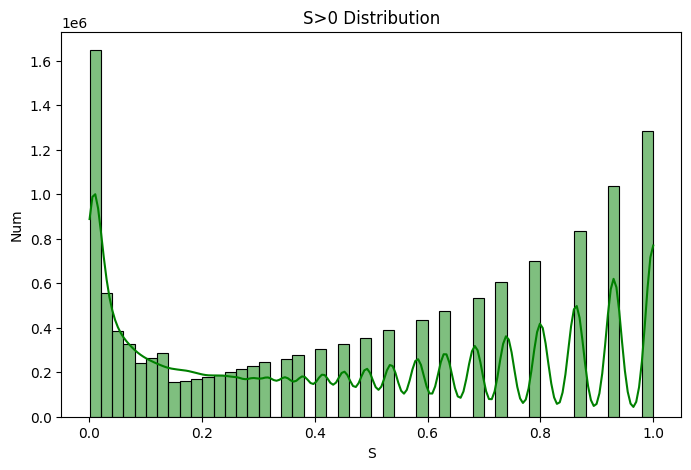

In [5]:
#complex distribution
#所有步数，除去S=0的，在不同S值区间的分布情况
df_nontrivial = df_moves[df_moves['S'] > 0]
hist_df_nontrivial = plot_hist_with_values(
    df_nontrivial,       # DataFrame
    col='S',             # 要绘制的列
    bins=50,             # 分50个区间
    kde=True,            # 显示 KDE 曲线
    color='green',       # 柱子颜色
    title='S>0 Distribution', 
    xlabel='S', 
    ylabel='Num'
)

=== S Distribution 每个区间步数 ===
0.000-0.020: 4628117           | 0.020-0.040: 555056
0.040-0.060: 385505            | 0.060-0.080: 328414
0.080-0.100: 242179            | 0.100-0.120: 262180
0.120-0.140: 287665            | 0.140-0.160: 154142
0.160-0.180: 162322            | 0.180-0.200: 171426
0.200-0.220: 178934            | 0.220-0.240: 189506
0.240-0.260: 202185            | 0.260-0.280: 213377
0.280-0.300: 227554            | 0.300-0.320: 244253
0.320-0.340: 0                 | 0.340-0.360: 261381
0.360-0.380: 0                 | 0.380-0.400: 279243
0.400-0.420: 302145            | 0.420-0.440: 0
0.440-0.460: 328779            | 0.460-0.480: 0
0.480-0.500: 355038            | 0.500-0.520: 0
0.520-0.540: 388693            | 0.540-0.560: 0
0.560-0.580: 0                 | 0.580-0.600: 432633
0.600-0.620: 0                 | 0.620-0.640: 476497
0.640-0.660: 0                 | 0.660-0.680: 0
0.680-0.700: 531271            | 0.700-0.720: 0
0.720-0.740: 0                 | 0.740-0.760: 

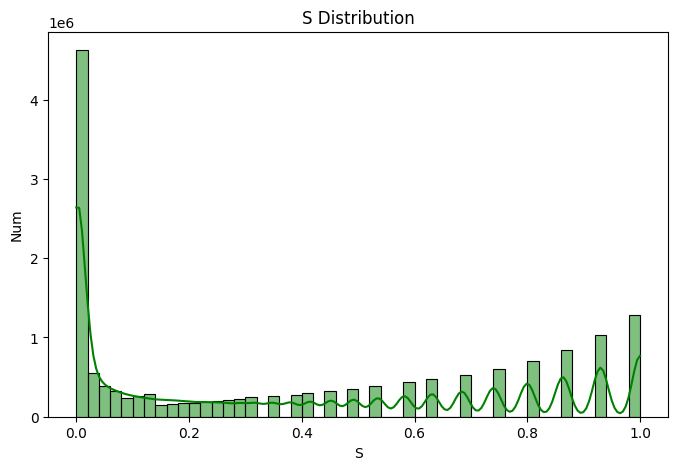

In [6]:
#所有步数，包含S=0，在不同S值区间的分布情况
plot_hist_with_values(df=df_moves, col='S', bins=50, kde=True, title='S Distribution', xlabel='S', ylabel='Num',color='green')

# The gap：   
for example:   
0.580-0.600: 432633    
0.600-0.620: 0    
0.620-0.640: 476497
$$S(\Delta_i) = \log_2 \left( 1 + e^{-\frac{\Delta_i}{10}} \right)$$在这个公式里，$\Delta_0 = 10$ 是个常数。变量只有 $\Delta_i = E_1 - E_2$。在国际象棋引擎（如 Stockfish）中，Centipawn（厘分）通常是整数 (Integer)。也就是说，$E_1$ 和 $E_2$ 都是整数（比如 20, 35, -10），那么它们的差值 $\Delta_i$ 只能是整数 (0, 1, 2, 3, 4...)，不可能是 1.5 或 2.33。让我们代入几个整数算一下 $S$ 的值：当 $\Delta = 6$ 时：$$S = \log_2(1 + e^{-0.6}) \approx \log_2(1 + 0.5488) \approx \mathbf{0.631}$$当 $\Delta = 7$ 时：$$S = \log_2(1 + e^{-0.7}) \approx \log_2(1 + 0.4965) \approx \mathbf{0.581}$$发现了吗？当分差从 6cp 变到 7cp 时，$S$ 值直接从 0.631 跳到了 0.581。中间的区间 (0.582 到 0.630) 是数学上的“真空地带”。无论你有多少局棋，只要引擎给出的分差是整数，就不可能算出 $0.600$ 或 $0.610$ 这样的 $S$ 值。这就是为什么你看到：0.580-0.600: 432633 (包含了 $\Delta=7$ 的 0.581)0.600-0.620: 0 (真空地带)0.620-0.640: 476497 (包含了 $\Delta=6$ 的 0.631)

=== Mistake / Blunder 's S distribution 每个区间步数 ===
0.000-0.020: 596336            | 0.020-0.040: 37584
0.040-0.060: 23124             | 0.060-0.080: 18318
0.080-0.100: 12872             | 0.100-0.120: 13487
0.120-0.140: 14203             | 0.140-0.160: 7229
0.160-0.180: 7455              | 0.180-0.200: 7634
0.200-0.220: 7682              | 0.220-0.240: 7967
0.240-0.260: 8285              | 0.260-0.280: 8580
0.280-0.300: 8766              | 0.300-0.320: 9165
0.320-0.340: 0                 | 0.340-0.360: 9443
0.360-0.380: 0                 | 0.380-0.400: 9857
0.400-0.420: 10035             | 0.420-0.440: 0
0.440-0.460: 10707             | 0.460-0.480: 0
0.480-0.500: 11073             | 0.500-0.520: 0
0.520-0.540: 11677             | 0.540-0.560: 0
0.560-0.580: 0                 | 0.580-0.600: 12440
0.600-0.620: 0                 | 0.620-0.640: 12801
0.640-0.660: 0                 | 0.660-0.680: 0
0.680-0.700: 13983             | 0.700-0.720: 0
0.720-0.740: 0                 | 0.740-0.760

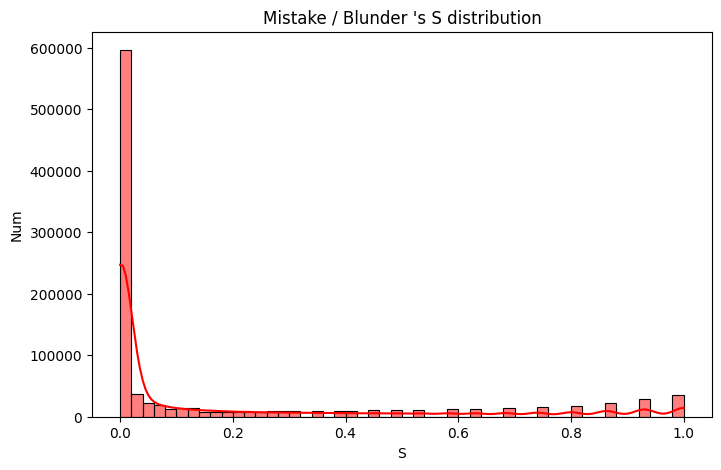

In [7]:
#mistake blunder distribution
# 只保留错误步
errors_df = df_moves[df_moves['Is_Error']==1]

plot_hist_with_values(df=errors_df, col='S', bins=50, kde=True, title="Mistake / Blunder 's S distribution", xlabel='S', ylabel='Num',color='red')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2796\2115724052.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stat_df = df_plot.groupby('bin').agg(



=== Error Probability across Complexity Levels ===
(-0.001, 0.02]: n=4628161, err=0.1288                   | (0.02, 0.04]: n=555058, err=0.0677
(0.04, 0.06]: n=385505, err=0.0600                      | (0.06, 0.08]: n=328416, err=0.0558
(0.08, 0.1]: n=242180, err=0.0532                       | (0.1, 0.12]: n=262181, err=0.0514
(0.12, 0.14]: n=287666, err=0.0494                      | (0.14, 0.16]: n=154144, err=0.0469
(0.16, 0.18]: n=162322, err=0.0459                      | (0.18, 0.2]: n=171429, err=0.0445
(0.2, 0.22]: n=178936, err=0.0429                       | (0.22, 0.24]: n=189507, err=0.0420
(0.24, 0.26]: n=202185, err=0.0410                      | (0.26, 0.28]: n=213379, err=0.0402
(0.28, 0.3]: n=227554, err=0.0385                       | (0.3, 0.32]: n=244254, err=0.0375
(0.32, 0.34]: n=0, err=nan                              | (0.34, 0.36]: n=261382, err=0.0361
(0.36, 0.38]: n=279244, err=0.0353                      | (0.38, 0.4]: n=0, err=nan
(0.4, 0.42]: n=302149, err=0.0

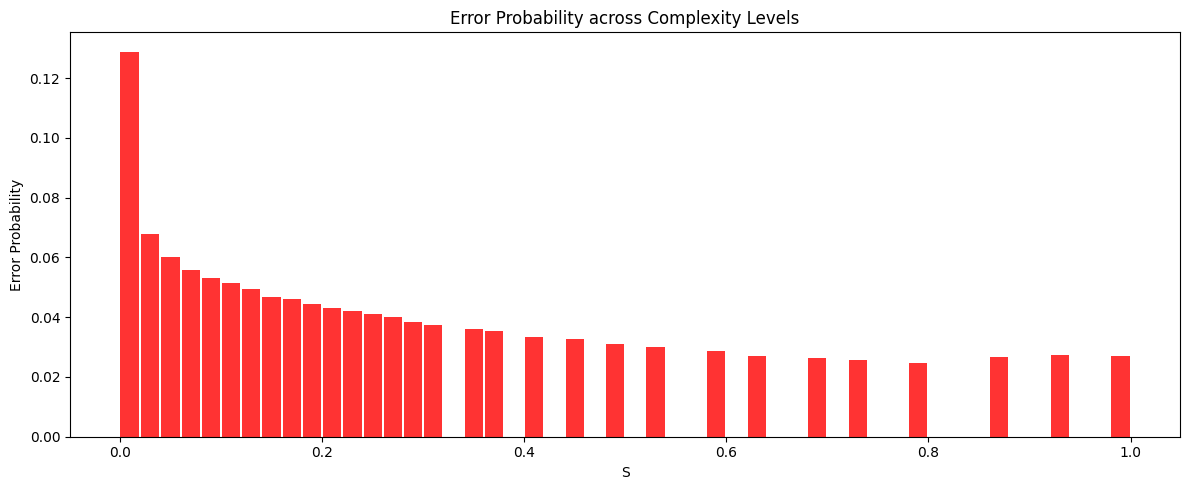

In [33]:
def plot_error_rate_equal_bins(df,value_col='S',error_col='Is_Error',bins=50,exclude_zero=False,title=None):
    """
    按 value_col 等宽分箱，计算 error_col 的均值（错误率），
    打印每个区间的样本数 & 错误率，并画柱状图（柱子宽度相等）。
    """
    df_plot = df.copy()
    if exclude_zero:
        df_plot = df_plot[df_plot[value_col] > 0]

    vmin = df_plot[value_col].min()
    vmax = df_plot[value_col].max()
    bin_edges = np.linspace(vmin, vmax, bins + 1)

    df_plot['bin'] = pd.cut(df_plot[value_col], bins=bin_edges, include_lowest=True)
    stat_df = df_plot.groupby('bin').agg(
        count=(error_col, 'size'),
        error_rate=(error_col, 'mean')
    ).reset_index()

    lines = [f"{row['bin']}: n={row['count']}, err={row['error_rate']:.4f}" 
             for _, row in stat_df.iterrows()]
    print(f"\n=== {title or 'Equal Bin Error Rate'} ===")
    for i in range(0, len(lines), 2):
        if i + 1 < len(lines):
            print(f"{lines[i]:<55} | {lines[i+1]}")
        else:
            print(lines[i])

    bin_centers = [interval.mid for interval in stat_df['bin']]
    bin_width = bin_edges[1] - bin_edges[0]

    plt.figure(figsize=(12,5))
    plt.bar(bin_centers, stat_df['error_rate'], width=bin_width*0.9, alpha=0.8, color='red')
    plt.xlabel(value_col)
    plt.ylabel("Error Probability")
    plt.title(title or "Error Probability vs Complexity (equal width bins)")
    plt.tight_layout()
    plt.show()


plot_error_rate_equal_bins(df_moves,value_col='S',error_col='Is_Error',bins=50,exclude_zero=False,title="Error Probability across Complexity Levels")

In [36]:
print(df_moves['Δi'].describe())
print(df_moves['Δi'].nunique())
#df_moves['Δi']有很多无穷大值，清洗一下
df_moves['Δi'] = df_moves['Δi'].replace([np.inf, -np.inf], np.nan)
df_moves_clean = df_moves.dropna(subset=['Δi'])
print(df_moves['Δi'].describe())


c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    16253227.0
mean            inf
std             NaN
min             0.0
25%             4.0
50%            15.0
75%            52.0
max             inf
Name: Δi, dtype: float64
5130
count    1.613260e+07
mean     1.448585e+02
std      9.145678e+02
min      0.000000e+00
25%      4.000000e+00
50%      1.500000e+01
75%      5.000000e+01
max      1.999800e+04
Name: Δi, dtype: float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_2796\2115724052.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stat_df = df_plot.groupby('bin').agg(



=== Error Probability across Complexity Levels ===
(-0.001, 399.96]: n=15481526, err=0.0606                | (399.96, 799.92]: n=436697, err=0.0661
(799.92, 1199.88]: n=54450, err=0.0341                  | (1199.88, 1599.84]: n=6424, err=0.0276
(1599.84, 1999.8]: n=574, err=0.0523                    | (1999.8, 2399.76]: n=56, err=0.1250
(2399.76, 2799.72]: n=25, err=0.1200                    | (2799.72, 3199.68]: n=32, err=0.2188
(3199.68, 3599.64]: n=28, err=0.2143                    | (3599.64, 3999.6]: n=29, err=0.2069
(3999.6, 4399.56]: n=32, err=0.1250                     | (4399.56, 4799.52]: n=37, err=0.2162
(4799.52, 5199.48]: n=22, err=0.3182                    | (5199.48, 5599.44]: n=32, err=0.1250
(5599.44, 5999.4]: n=37, err=0.2703                     | (5999.4, 6399.36]: n=33, err=0.2424
(6399.36, 6799.32]: n=31, err=0.2581                    | (6799.32, 7199.28]: n=36, err=0.1111
(7199.28, 7599.24]: n=49, err=0.3469                    | (7599.24, 7999.2]: n=27, err=0.481

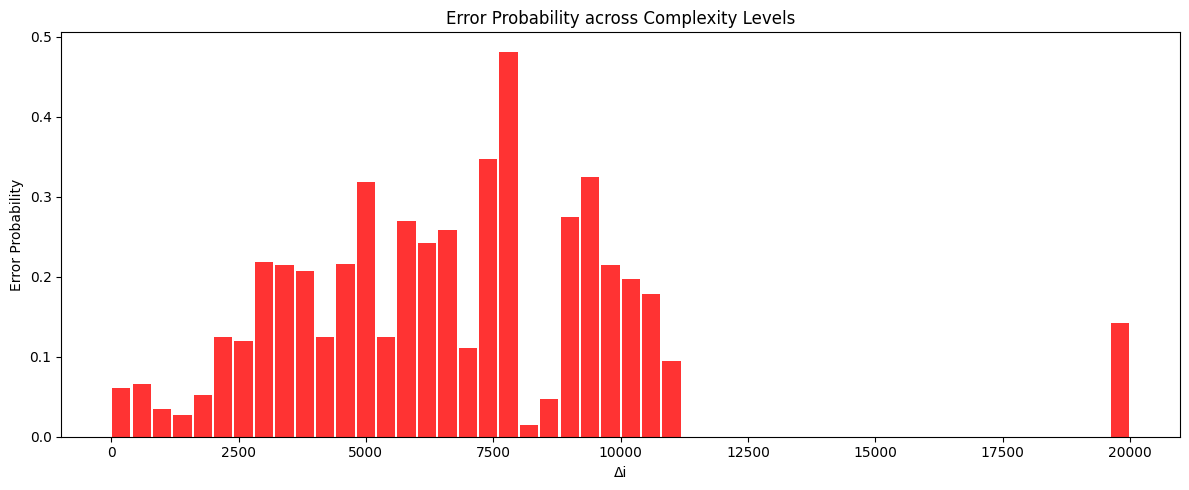

In [37]:
plot_error_rate_equal_bins(df_moves,value_col='Δi',error_col='Is_Error',bins=50,exclude_zero=False,title="Error Probability across Complexity Levels")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2796\1312062164.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stat_df = df_plot.groupby('bin').agg(



=== Error Probability across Complexity Levels ===
(-0.001, 0.02]: n=4628161, err=0.1288                   | (0.02, 0.04]: n=555058, err=0.0677
(0.04, 0.06]: n=385505, err=0.0600                      | (0.06, 0.08]: n=328416, err=0.0558
(0.08, 0.1]: n=242180, err=0.0532                       | (0.1, 0.12]: n=262181, err=0.0514
(0.12, 0.14]: n=287666, err=0.0494                      | (0.14, 0.16]: n=154144, err=0.0469
(0.16, 0.18]: n=162322, err=0.0459                      | (0.18, 0.2]: n=171429, err=0.0445
(0.2, 0.22]: n=178936, err=0.0429                       | (0.22, 0.24]: n=189507, err=0.0420
(0.24, 0.26]: n=202185, err=0.0410                      | (0.26, 0.28]: n=213379, err=0.0402
(0.28, 0.3]: n=227554, err=0.0385                       | (0.3, 0.32]: n=244254, err=0.0375
(0.32, 0.34]: n=0, err=nan                              | (0.34, 0.36]: n=261382, err=0.0361
(0.36, 0.38]: n=279244, err=0.0353                      | (0.38, 0.4]: n=0, err=nan
(0.4, 0.42]: n=302149, err=0.0

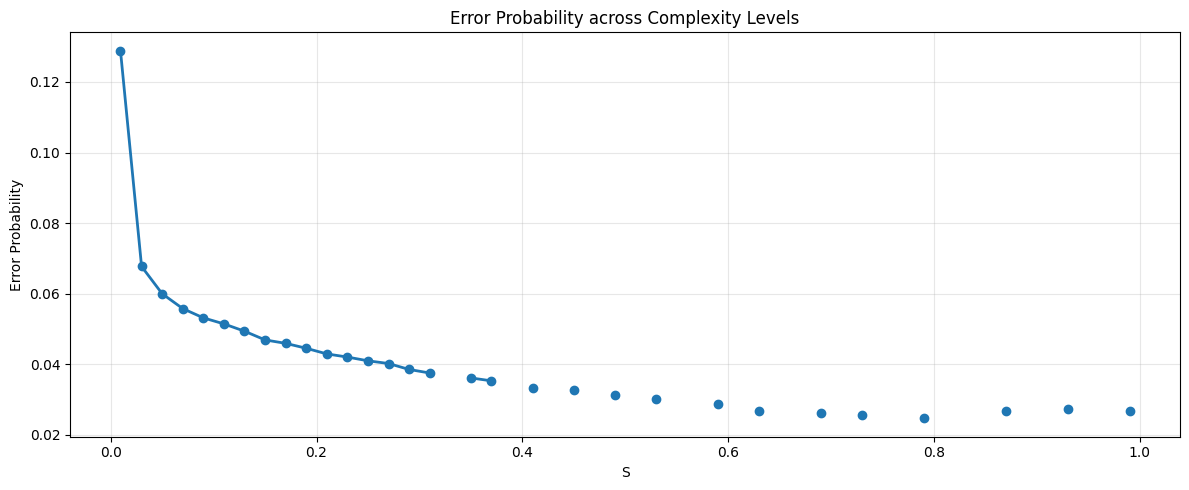

In [27]:
def plot_error_rate_equal_bins(df,value_col='S',error_col='Is_Error',bins=50,exclude_zero=False,title=None):
    """
    按 value_col 等宽分箱，计算 error_col 的均值（错误率），
    打印每个区间的样本数 & 错误率，并画柱状图（柱子宽度相等）。
    """
    df_plot = df.copy()
    if exclude_zero:
        df_plot = df_plot[df_plot[value_col] > 0]

    bin_edges = np.linspace(0, 1, bins+1)
    df_plot['bin'] = pd.cut(df_plot[value_col], bins=bin_edges, include_lowest=True)
    stat_df = df_plot.groupby('bin').agg(
        count=(error_col, 'size'),
        error_rate=(error_col, 'mean')
    ).reset_index()

    lines = [f"{row['bin']}: n={row['count']}, err={row['error_rate']:.4f}" 
             for _, row in stat_df.iterrows()]
    print(f"\n=== {title or 'Equal Bin Error Rate'} ===")
    for i in range(0, len(lines), 2):
        if i + 1 < len(lines):
            print(f"{lines[i]:<55} | {lines[i+1]}")
        else:
            print(lines[i])

    bin_centers = stat_df['bin'].apply(lambda x: x.mid)

    plt.figure(figsize=(12,5))
    plt.plot(
    bin_centers,
    stat_df['error_rate'],
    marker='o',
    linestyle='-',
    linewidth=2
)
    plt.xlabel(value_col)
    plt.ylabel("Error Probability")
    plt.title(title or "Error Probability vs Complexity")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_error_rate_equal_bins(df_moves,value_col='S',error_col='Is_Error',bins=50,exclude_zero=False,title="Error Probability across Complexity Levels")

# The results were contrary to intuition.

force moves check

In [9]:
force_moves_csv=r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_moves_df=pd.read_csv(force_moves_csv)

In [10]:
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [int(x)]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [int(v)]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

force_moves_df['Forced_Move_Idx_List'] = force_moves_df['Forced_Move_Idx_List'].apply(ensure_list)

forced_expanded = []

for idx, row in force_moves_df.iterrows():
    game_id = row['Game_ID']
    for move_idx in row['Forced_Move_Idx_List']:
        forced_expanded.append({'Game_ID': game_id, 'Move_Idx': move_idx, 'Is_Forced': 1})

df_forced_expanded = pd.DataFrame(forced_expanded, columns=['Game_ID', 'Move_Idx', 'Is_Forced'])

cols_to_drop = [col for col in df_moves.columns if 'Is_Forced' in col]
df_moves = df_moves.drop(columns=cols_to_drop)

df_moves = df_moves.merge(df_forced_expanded, on=['Game_ID','Move_Idx'], how='left')
df_moves['Is_Forced'] = df_moves['Is_Forced'].fillna(0).astype(int)

In [11]:
df_moves.shape

(16253120, 12)

In [12]:
# S=0 且 Is_Forced=1 的行
forced_s_zero = df_moves[(df_moves['S'] == 0) & (df_moves['Is_Forced'] == 1)]
print(forced_s_zero.head())

print("S=0 且 Is_Forced=1 的步数:", len(forced_s_zero))
print("S=0的步数：", len(df_moves[(df_moves['S'] == 0)]))

     Game_ID  Move_Idx                      Player  Color    S      E1   E2  \
266        8        70  Mukhammadali Abdurakhmonov  Black  0.0    40.0  inf   
618       15        46            Garnik Nersesyan  Black  0.0 -9998.0  inf   
620       15        48            Garnik Nersesyan  Black  0.0 -9999.0  inf   
784       18        52             Viktor Parfenov  Black  0.0 -9999.0  inf   
984       22        54          Oleksii Karvatskyi  Black  0.0  -175.0  inf   

       P Judgment_Raw  Is_Error  Is_Blunder  Is_Forced  
266  1.0            -         0           0          1  
618  1.0            -         0           0          1  
620  1.0            -         0           0          1  
784  1.0            -         0           0          1  
984  1.0            -         0           0          1  
S=0 且 Is_Forced=1 的步数: 120631
S=0的步数： 2980689


force_movesnumbers：120631
S 值分布（强制走子数量）：
S
0.0    120631
Name: count, dtype: int64


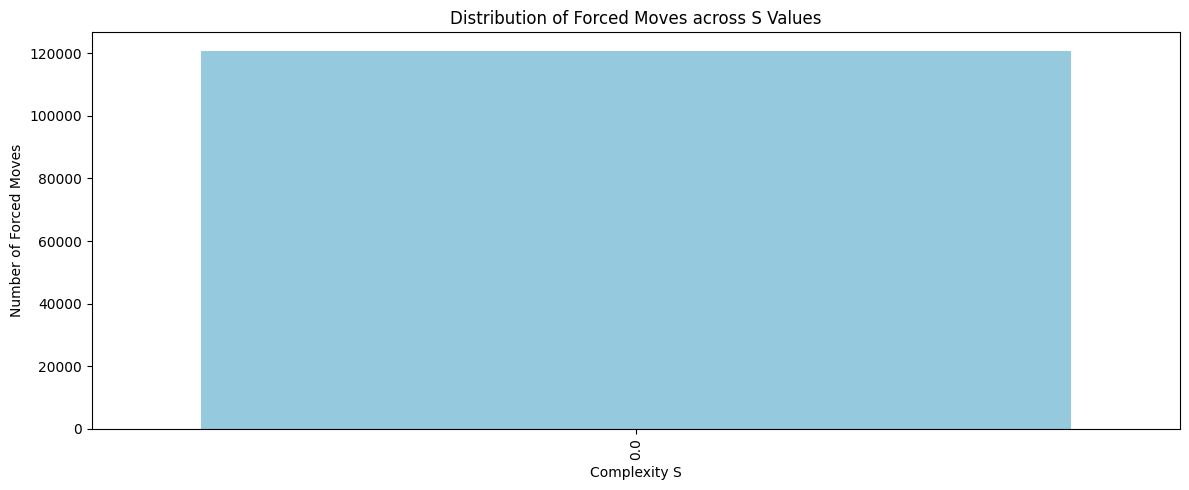

In [23]:
# 筛选出强制走子的步
forced_moves = df_moves[df_moves['Is_Forced'] == 1]
print(f"force_movesnumbers：{len(forced_moves)}")
# 统计不同 S 值下的强制走子数量
S_distribution = forced_moves['S'].value_counts().sort_index()  
print("S 值分布（强制走子数量）：")
print(S_distribution)

plt.figure(figsize=(12,5))
sns.barplot(x=S_distribution.index, y=S_distribution.values, color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Complexity S")
plt.ylabel("Number of Forced Moves")
plt.title("Distribution of Forced Moves across S Values")
plt.tight_layout()
plt.show()


Endgame all have S next to 0 ?

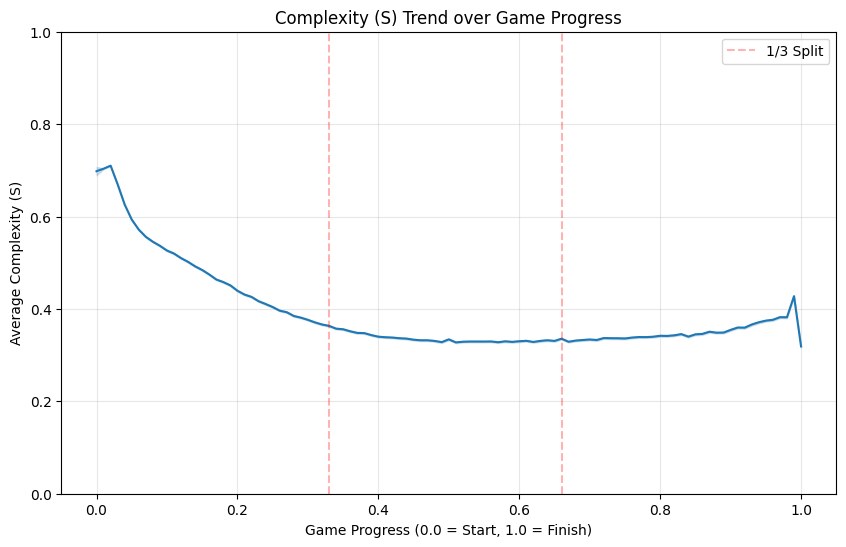

各阶段平均复杂度：
Relative_Stage(temp)
Endgame (66-100%)      0.349099
Middlegame (33-66%)    0.335510
Opening (0-33%)        0.484773
Name: S, dtype: float64


In [14]:
#观察相对进度和S的关系
df_moves['Total_Moves']=df_moves.groupby('Game_ID')['Move_Idx'].transform('max')
df_moves['Progress'] = df_moves['Move_Idx'] / df_moves['Total_Moves']
def get_relative_stage(progress):
    if progress <= 0.33:
        return 'Opening (0-33%)'
    elif progress <= 0.66:
        return 'Middlegame (33-66%)'
    else:
        return 'Endgame (66-100%)'
df_moves['Relative_Stage(temp)'] = df_moves['Progress'].apply(get_relative_stage)

plt.figure(figsize=(10, 6))
sns.lineplot(x=df_moves['Progress'].round(2), y=df_moves['S'])
plt.ylim(bottom=0, top=1.0)
plt.title("Complexity (S) Trend over Game Progress")
plt.xlabel("Game Progress (0.0 = Start, 1.0 = Finish)")
plt.ylabel("Average Complexity (S)")
plt.axvline(0.33, color='r', linestyle='--', alpha=0.3, label='1/3 Split')
plt.axvline(0.66, color='r', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("各阶段平均复杂度：")
print(df_moves.groupby('Relative_Stage(temp)')['S'].mean())

低复杂度步数 (S < 0.05) 总数: 5369443
占总数据比例: 0.33036383168277844


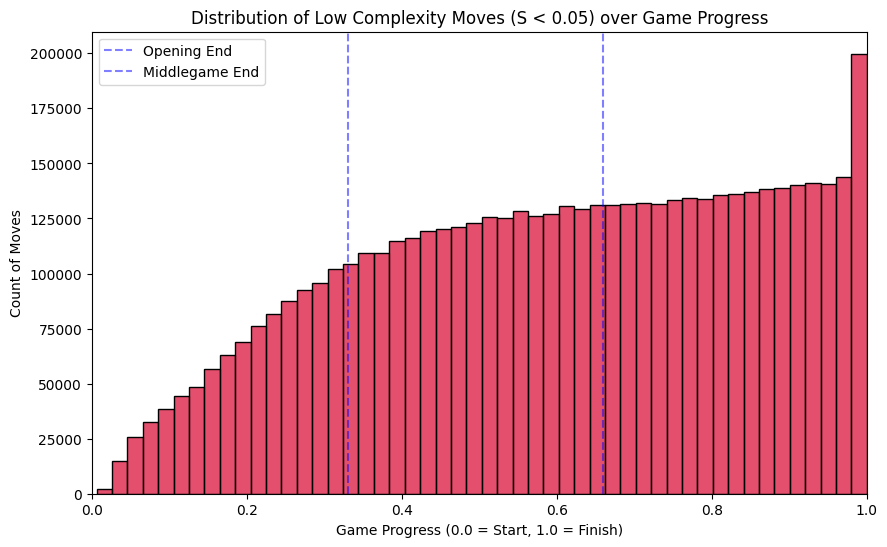

=== 低复杂度步数在各阶段的分布比例 ===
Relative_Stage(temp)
Endgame (66-100%)      0.445489
Middlegame (33-66%)    0.375437
Opening (0-33%)        0.179074
Name: proportion, dtype: float64


In [15]:
low_complexity_moves = df_moves[df_moves['S'] < 0.05].copy()    #也可以换成S==0.00 总之都是尾局很多
print(f"低复杂度步数 (S < 0.05) 总数: {len(low_complexity_moves)}")
print(f"占总数据比例: {len(low_complexity_moves) / len(df_moves)}")

plt.figure(figsize=(10, 6))
sns.histplot(data=low_complexity_moves, x='Progress', bins=50, kde=False, color='crimson')
plt.title("Distribution of Low Complexity Moves (S < 0.05) over Game Progress")
plt.xlabel("Game Progress (0.0 = Start, 1.0 = Finish)")
plt.ylabel("Count of Moves")
plt.xlim(0, 1.0)
plt.axvline(0.33, color='blue', linestyle='--', alpha=0.5, label='Opening End')
plt.axvline(0.66, color='blue', linestyle='--', alpha=0.5, label='Middlegame End')
plt.legend()

plt.show()

print("=== 低复杂度步数在各阶段的分布比例 ===")
print(low_complexity_moves['Relative_Stage(temp)'].value_counts(normalize=True))

=== 低复杂度 (S < 0.05) 下，各阶段的失误率 ===
                      Error_Rate  Total_Moves
Relative_Stage(temp)                         
Endgame (66-100%)       0.137908      2392027
Middlegame (33-66%)     0.122597      2015886
Opening (0-33%)         0.071087       961530


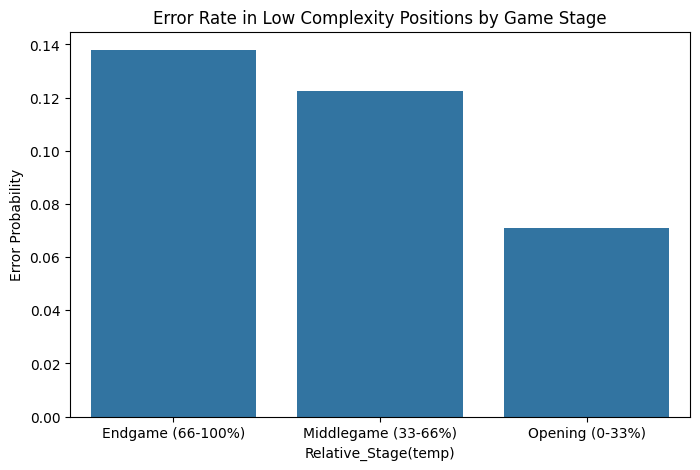

In [16]:
low_complexity_df = df_moves[df_moves['S'] < 0.05]

# 算出每个阶段内部的失误率
# 在 Opening 的简单局面里，失误率是多少？在 Endgame 的简单局面里，失误率又是多少？
stage_error_analysis = low_complexity_df.groupby('Relative_Stage(temp)')['Is_Error'].agg(['mean', 'count'])

stage_error_analysis.columns = ['Error_Rate', 'Total_Moves']
print("=== 低复杂度 (S < 0.05) 下，各阶段的失误率 ===")
print(stage_error_analysis.sort_values('Error_Rate', ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x=stage_error_analysis.index, y=stage_error_analysis['Error_Rate'])
plt.title("Error Rate in Low Complexity Positions by Game Stage")
plt.ylabel("Error Probability")
plt.show()

In [17]:
df_moves.head()

,Game_ID,Move_Idx,Player,Color,S,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Is_Forced,Total_Moves,Progress,Relative_Stage(temp)
0,1,1,Petra Kejzar,White,0.492,32.0,23.0,0.711,-,0,0,0,26,0.038462,Opening (0-33%)
1,1,2,Daniel Barria,Black,0.684,-20.0,-25.0,0.622,-,0,0,0,26,0.076923,Opening (0-33%)
2,1,3,Petra Kejzar,White,0.930,20.0,19.0,0.525,-,0,0,0,26,0.115385,Opening (0-33%)
3,1,4,Daniel Barria,Black,0.380,-20.0,-32.0,0.769,-,0,0,0,26,0.153846,Opening (0-33%)
4,1,5,Petra Kejzar,White,0.863,21.0,19.0,0.550,-,0,0,0,26,0.192308,Opening (0-33%)


In [18]:
df_moves.shape

(16253120, 15)

In [19]:
elo_info=pd.read_csv(r"C:\Users\Administrator\Desktop\Chess\ELO\temp.csv",usecols=['uid','player', 'My_Elo'] )
elo_info=elo_info[['uid','player', 'My_Elo']].rename(columns={'My_Elo':'ELO'})
elo_info=elo_info.set_index(['uid', 'player'])['ELO']
elo_info.head()

uid     player    
540927  107degrees    2114
541102  107degrees    2111
541585  107degrees    2124
541718  107degrees    2132
541348  107degrees    2116
Name: ELO, dtype: int64

In [24]:
df_moves = df_moves.merge(
    elo_info,
    left_on=['Game_ID', 'Player'],   # df_moves 中的列
    right_on=['uid', 'player'],      # elo_info 中的列
    how='left'
)
df_moves.head()

,Game_ID,Move_Idx,Player,Color,S,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Is_Forced,Total_Moves,Progress,Relative_Stage(temp),ELO
0,1,1,Petra Kejzar,White,0.492,32.0,23.0,0.711,-,0,0,0,26,0.038462,Opening (0-33%),2177
1,1,2,Daniel Barria,Black,0.684,-20.0,-25.0,0.622,-,0,0,0,26,0.076923,Opening (0-33%),2637
2,1,3,Petra Kejzar,White,0.930,20.0,19.0,0.525,-,0,0,0,26,0.115385,Opening (0-33%),2177
3,1,4,Daniel Barria,Black,0.380,-20.0,-32.0,0.769,-,0,0,0,26,0.153846,Opening (0-33%),2637
4,1,5,Petra Kejzar,White,0.863,21.0,19.0,0.550,-,0,0,0,26,0.192308,Opening (0-33%),2177


ELO info   
count    9606.000000   
mean     2492.946908   
std       291.854408   
min       353.000000   
25%      2338.000000   
50%      2514.000000   
75%      2675.000000    
max      3319.000000   

In [ ]:
high=['Hikaru Nakamura', 'Magnus Carlsen', 'Nihal Sarin', 'Parham Maghsoodloo']